### Import Libraries

In [1]:
import tensorflow as tf
import numpy as np
import random
import os

# Reproducibility
seed = 2
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Optional: disable eager execution (if using graph mode code)
tf.compat.v1.disable_eager_execution()

# Session config
session_conf = tf.compat.v1.ConfigProto(
    intra_op_parallelism_threads=1,
    inter_op_parallelism_threads=1
)
sess = tf.compat.v1.Session(config=session_conf)

# Set this session as default for everything that follows
# No set_session needed — use a context manager instead
with sess.as_default():
    # your model/code here
    pass


2025-06-09 08:40:44.217459: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-09 08:40:44.230101: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749458444.240938 1484782 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749458444.243962 1484782 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749458444.253193 1484782 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
import warnings
warnings.filterwarnings('ignore')

from pylab import *

import pandas as pd
import pickle
import time
import sys
import json
import os

# import statsmodels
# import statsmodels.api as sm
# from statsmodels.tsa.stattools import coint, adfuller

import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Import Datetime and the Pandas DataReader
from datetime import datetime
from pandas_datareader import data, wb

# Import scikit instruments
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn import preprocessing
from sklearn.metrics import silhouette_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler


# Import keras
from keras.models import Sequential, load_model
from keras.layers import Dense, Flatten, LSTM, GRU, Dropout, TimeDistributed
from keras.optimizers import SGD, Adam
from tensorflow.keras.layers import Conv1D, MaxPooling1D 
#from keras.layers.convolutional import Conv1D
#from keras.layers.convolutional import MaxPooling1D
from keras.callbacks import EarlyStopping, ProgbarLogger

### Import Classes

In [3]:
os.getcwd()

'/mnt/c/Users/ansel/AppData/Local/Programs/Microsoft VS Code'

In [4]:
os.chdir('/mnt/d/GitHub/WQU-Capstone/notebooks/classes')

os.getcwd()

'/mnt/d/GitHub/WQU-Capstone/notebooks/classes'

In [5]:
%load_ext autoreload
%aimport class_SeriesAnalyser, class_Trader, class_DataProcessor, class_ForecastingTrader
%autoreload 1

I0000 00:00:1749458446.489527 1484782 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [6]:
series_analyser = class_SeriesAnalyser.SeriesAnalyser()
trader = class_Trader.Trader()
data_processor = class_DataProcessor.DataProcessor()
forecasting_trader = class_ForecastingTrader.ForecastingTrader()

Function to evaluate forecasting results:

In [7]:
def evaluate_forecasting(n_pairs, true_values, prediction_values):
    mse, mae, rmse, accuracy, bias = list(), list(), list(), list(), list()
    std_dev = list()
    for i in range(n_pairs):
        mse.append(mean_squared_error(true_values[i], prediction_values[i]))
        rmse.append(np.sqrt(mean_squared_error(true_values[i], prediction_values[i])))
        mae.append(mean_absolute_error(true_values[i], prediction_values[i]))
        accuracy.append(forecasting_trader.calculate_direction_accuracy(true_values[i], prediction_values[i]))
        bias.append((true_values[i] - prediction_values[i]).mean())
        std_dev.append(prediction_values[i].std())
    print('{:.2f}E-4'.format(np.mean(mse)*10000))#Average MSE: 
    print('{:.2f}E-3'.format(np.mean(rmse)*1000))#Average RMSE: 
    print('{:.2f}E-3'.format(np.mean(mae)*1000))#Average RMSE: 
    print('{:.2f}%'.format(np.mean(accuracy)))#Average Directional Accuracy: 
    #print('Bias: {:.2f}E-4'.format(np.mean(bias)*10000))
    #print('Average Standard Deviation from prediction signal ', np.mean(std_dev))
    
    return mse, mae, rmse, accuracy

### LSTM

In [8]:
def plot_loss(history, title, epoch_stop, metric='mse'):
    """
    Function to plot loss function.
    Arguments:
    history: History object with data from training.
    title: Plot title.
    """
    plt.figure(figsize=(7,5))
    #plt.grid()
    if metric == 'mse':
        plt.plot(history['loss'], label = "Training MSE")
        plt.plot(history['val_loss'], label = "Validation MSE")
        plt.plot([epoch_stop], [history['val_loss'][epoch_stop]],'o', color='Red', markersize=7)
        plt.annotate(
            'Best Epoch: 41\nValidation MSE:{:.3f}'.format(history['val_loss'][epoch_stop]),
            xy=(epoch_stop, history['val_loss'][epoch_stop]),
            xytext=(-20, 20),
            textcoords='offset points', ha='left', va='bottom',
            bbox=dict(boxstyle='round,pad=0.5', fc='grey', alpha=0.5),
            arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))
        plt.ylim((0,1.2))
        plt.ylabel('Mean Squared Error', size=12)
    elif metric == 'mae':
        plt.plot(history['mean_absolute_error'], label = "Training MAE")
        plt.plot(history['val_mean_absolute_error'], label = "Validation MAE")
        plt.plot([epoch_stop], [history['val_mean_absolute_error'][epoch_stop]],'o', color='Red', markersize=7)
        plt.annotate(
            'Best Epoch: 41\nValidation MAE:{:.3f}'.format(history['val_mean_absolute_error'][epoch_stop]),
            xy=(epoch_stop, history['val_mean_absolute_error'][epoch_stop]),
            xytext=(-20, 20),
            textcoords='offset points', ha='left', va='bottom',
            bbox=dict(boxstyle='round,pad=0.5', fc='grey', alpha=0.5),
            arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))
        plt.ylim((0,1.2))
        plt.ylabel('Mean Absolute Error', size=12)
    plt.xlabel('Epochs', size=12)
    plt.legend()
    plt.savefig('{}_history.png'.format(metric), bbox='tight')
    
def plot_predictions(summaries):
    
    n_pairs = len(summaries)
    fig, ax = plt.subplots(n_pairs, 1, figsize=(20,25))
    
    for i in range(n_pairs):
        #title('Pair: {}'.format(i))
        predictions = summaries[i]['prediction(t)']
        spread = summaries[i]['spread(t)']
        ax[i].plot(predictions, 'b')
        ax[i].plot(spread, 'r')
    return None

In [9]:
def read_models(path='models/'):
    all_models = [] # Creates an empty list
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith(".pkl"):
                with open(path+file, 'rb') as f:
                    models = pickle.load(f)
                all_models.append(models)
                
    return all_models

In [10]:
current_path='/mnt/d/GitHub/WQU-Capstone/notebooks/CAE_9-6-25' #current_path=('/mnt/d/GitHub/WQU-Capstone/data/')
with open(f'{current_path}/CAE_selected_pairs.pickle', 'rb') as handle: 
    pairs = pickle.load(handle)
len(pairs)

99

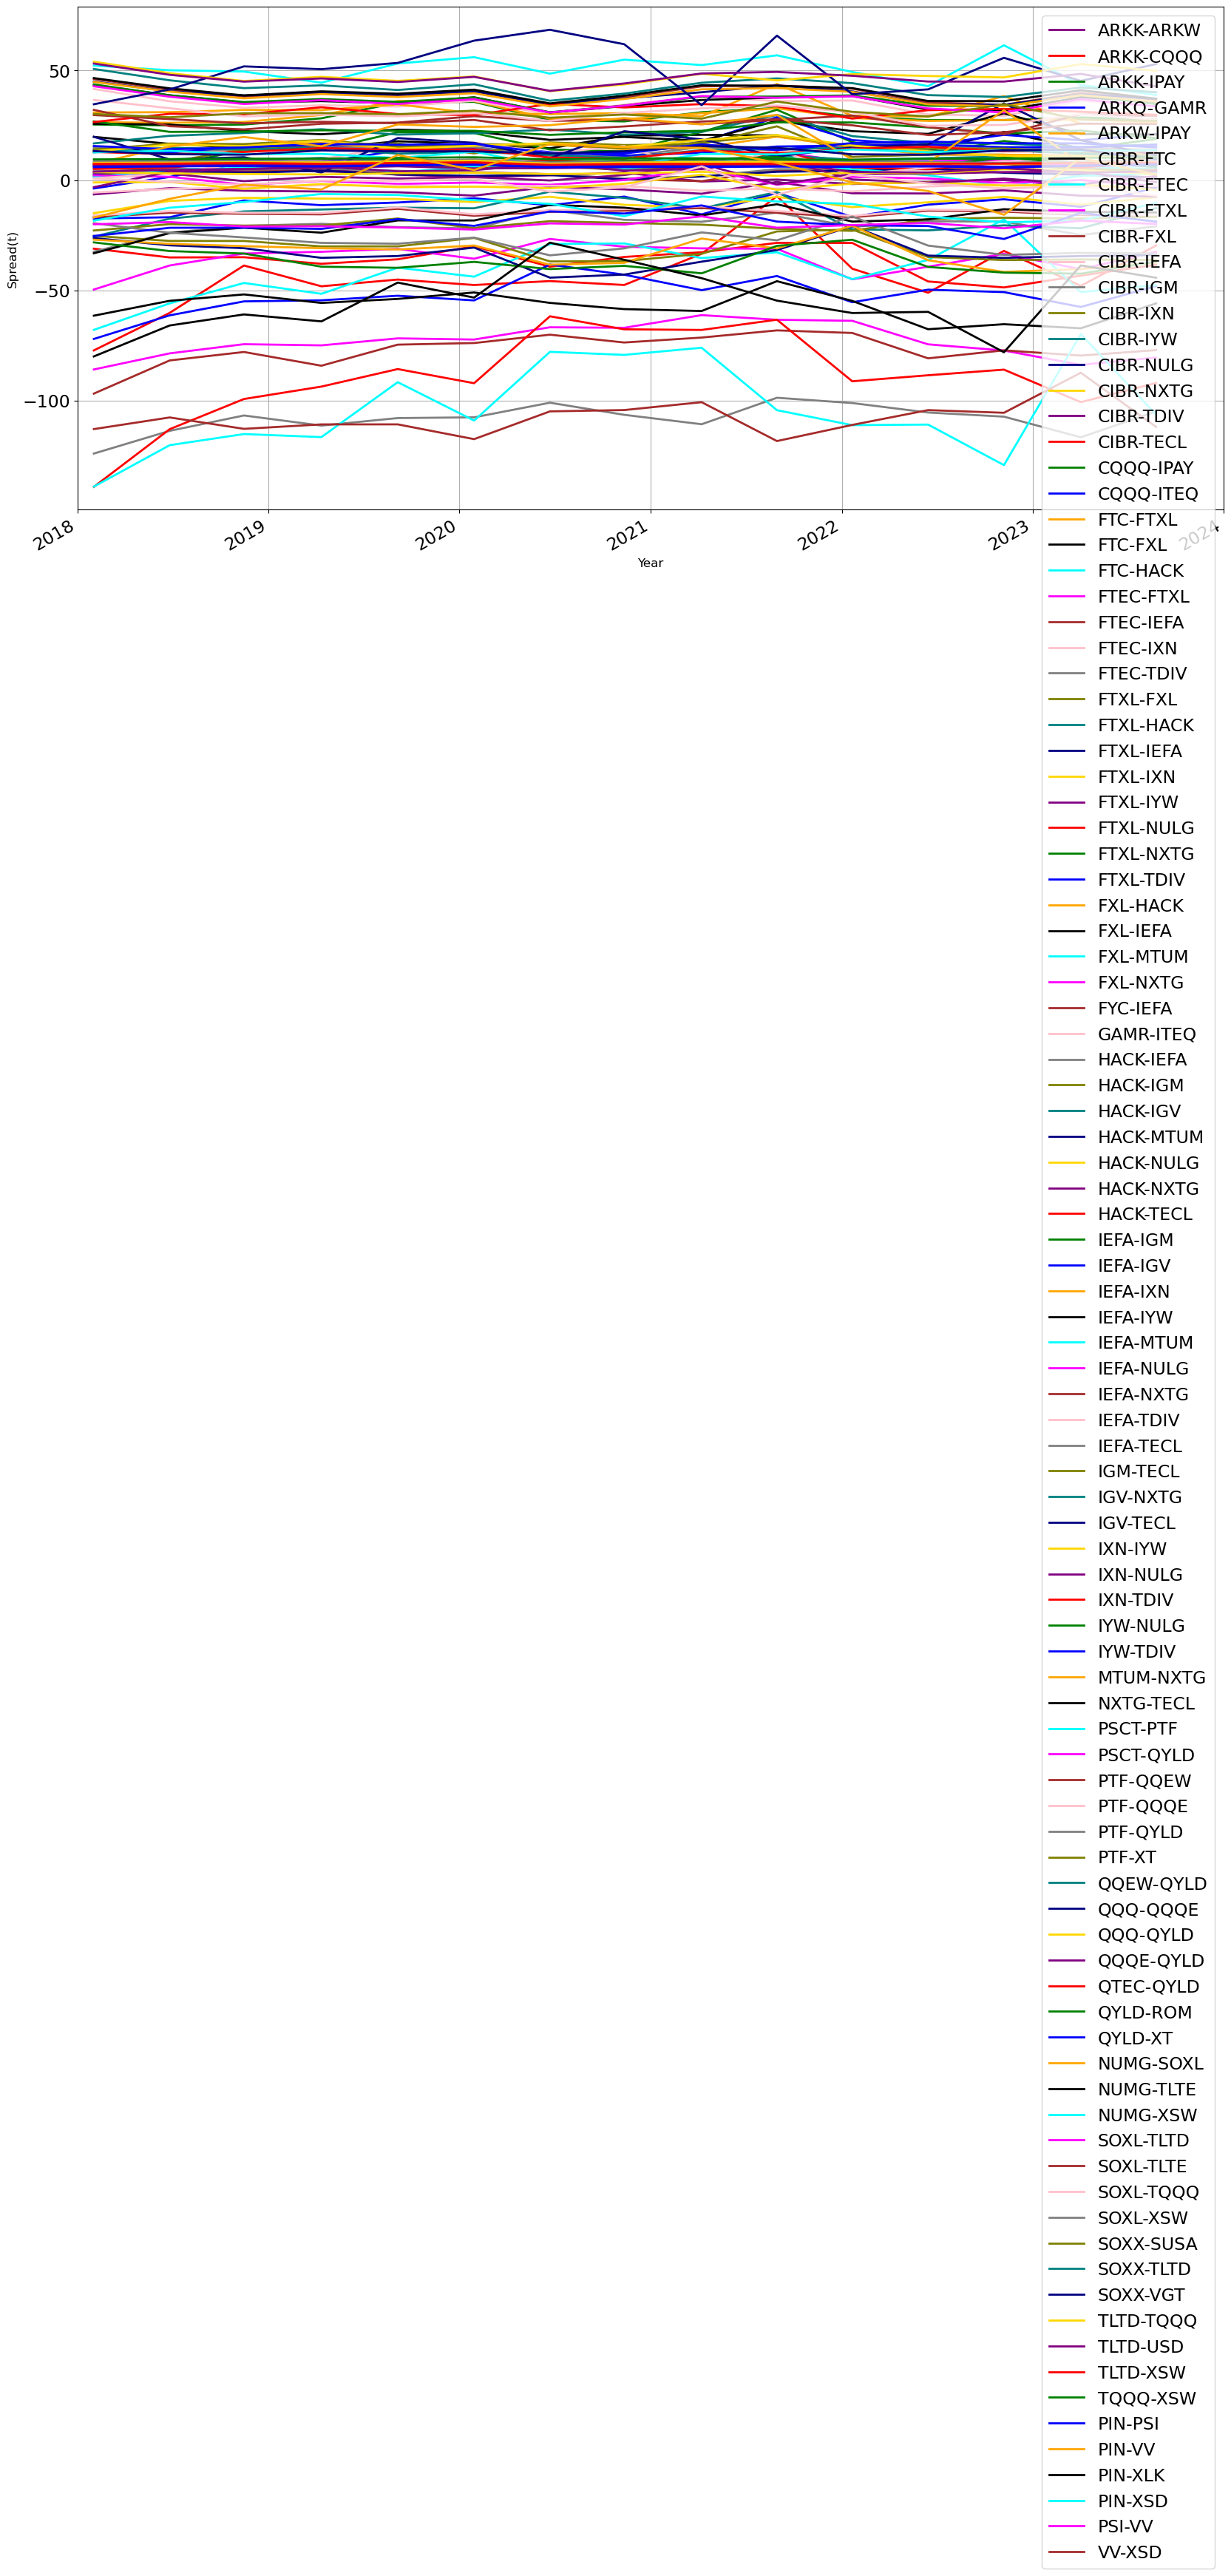

In [11]:
#markers= ["o","s","+","x","<"]
plt.rcParams.update({'font.size': 17})
colors = [
    'purple', 'red', 'green', 'blue', 'orange',
    'black', 'cyan', 'magenta', 'brown', 'pink',
    'gray', 'olive', 'teal', 'navy', 'gold'
]
for i in range(len(pairs)):
    pairs[i][2]['spread'][::100].plot(figsize=(20,10), grid=True, label='{}-{}'.format(pairs[i][0],pairs[i][1]), c=colors[i % len(colors)], linewidth=2)
plt.ylabel('Spread(t)',size=12)
plt.xlabel('Year',size=12)
plt.xlim(('2018', '2024'))
plt.legend()
#plt.savefig('spreads.png', bbox_inches='tight', pad_inches=0.05)

## Validation Set

In [12]:
rnn_models = read_models(path=f'{current_path}/models/lstm/') 
rnn_models

[[{'leg1': 'ARKK',
   'leg2': 'ARKW',
   'standardization_dict': 'scaler',
   'history': {'loss': [0.38291600346565247,
     0.17985853552818298,
     0.15425358712673187,
     0.13776829838752747,
     0.12546344101428986,
     0.11526695638895035,
     0.10637044161558151,
     0.0985233336687088,
     0.09167661517858505,
     0.08582355082035065,
     0.08091457188129425,
     0.07682382315397263,
     0.07336579263210297,
     0.07035781443119049,
     0.06767019629478455,
     0.0652289167046547,
     0.0629926398396492,
     0.06093404442071915,
     0.059032734483480453,
     0.05727216228842735,
     0.055637869983911514,
     0.05411747097969055,
     0.05269939452409744,
     0.051373161375522614,
     0.050129227340221405,
     0.048959214240312576,
     0.04785608500242233,
     0.04681351035833359,
     0.04582630842924118,
     0.04489004984498024,
     0.04400094971060753,
     0.04315555468201637,
     0.04235095903277397,
     0.04158451780676842,
     0.0408538207411

In [13]:
etf_list = pd.read_excel(f'{current_path}/tech_etfs.xlsx')
ticker_segment_dict = dict(zip(etf_list['Ticker'], etf_list['Description']))
ticker_segment_dict

{'ARKK': 'ARK Innovation ETF',
 'ARKQ': 'ARK Autonomous Technology & Robotics ETF',
 'ARKW': 'ARK Next Generation Internet ETF',
 'CIBR': 'First Trust NASDAQ Cybersecurity ETF',
 'CQQQ': 'Invesco China Technology ETF',
 'CWEB': 'Direxion Daily CSI China Internet Bull 2X Shares',
 'DTEC': 'ALPS Disruptive Technologies ETF',
 'FDN': 'First Trust Dow Jones Internet Index Fund',
 'FTC': 'First Trust Large Cap Growth AlphaDEX Fund',
 'FTEC': 'Fidelity MSCI Information Technology Index ETF',
 'FTXL': 'First Trust Nasdaq Semiconductor ETF',
 'FXI': 'iShares China Large-Cap ETF',
 'FXL': 'First Trust Technology AlphaDEX Fund',
 'FXP': 'ProShares UltraShort FTSE China 50',
 'FYC': 'First Trust Small Cap Growth AlphaDEX Fund',
 'GAMR': 'Wedbush ETFMG Video Game Tech ETF',
 'HACK': 'ETFMG Prime Cyber Security ETF',
 'IDLV': 'Invesco S&P International Developed Low Volatility ETF',
 'IDMO': 'Invesco S&P International Developed Momentum ETF',
 'IDX': 'VanEck Vectors Indonesia Index ETF',
 'IEFA': '

In [14]:
# model to test
n_in = 24
hidden_nodes = [[50]]
low_quantile = 0.10
high_quantile = 0.90
train_val_split = '01-01-2023'

current_path=(f'{current_path}/models/lstm/')

In [15]:
model_rnn, cumret_val, sharperatio_val,summaries_rnn, balance_summaries_rnn = \
            forecasting_trader.run_specific_model(
                                                n_in, 
                                                hidden_nodes, 
                                                pairs,
                                                path=current_path,
                                                train_val_split=train_val_split,
                                                low_quantile=low_quantile, 
                                                high_quantile=high_quantile, 
                                                lag=1,
                                                )

In [16]:
performance_rnn = [(summaries_rnn[i], balance_summaries_rnn[i]) for i in range(len(pairs))]
performance_rnn

[(            prediction(t)  prediction(t+1)  spread(t)  predicted_change(%)  \
  date                                                                         
  2023-01-03       0.346736                0   0.166997             0.000000   
  2023-01-04       0.256529                0   0.472854            53.612973   
  2023-01-05       0.417772                0   0.841801           -11.648828   
  2023-01-06       0.742954                0   0.472313           -11.742344   
  2023-01-09       0.659284                0   0.618503            39.586217   
  ...                   ...              ...        ...                  ...   
  2023-12-22      -7.688366                0  -7.876715             4.695216   
  2023-12-26      -7.647472                0  -7.677953             2.910386   
  2023-12-27      -7.542828                0  -8.075830             1.759910   
  2023-12-28      -7.625160                0  -7.964927             5.580478   
  2023-12-29      -7.643607             

Annual ROI:  1.3518634891531933
25.252525252525253 % of the pairs had positive returns
Sharpe Ratio assumming IID returns:  -6.369234839541553
Autocorrelation:  -0.0864303005962894
Daily Sharpe Ratio -0.3880606461670687
Total number of trades:  143
Positive trades:  100
Negative trades:  43
Total Drawdown Days: 111 days
Max DD period: 0 days
Maximum drawdown of portfolio: -0.30%


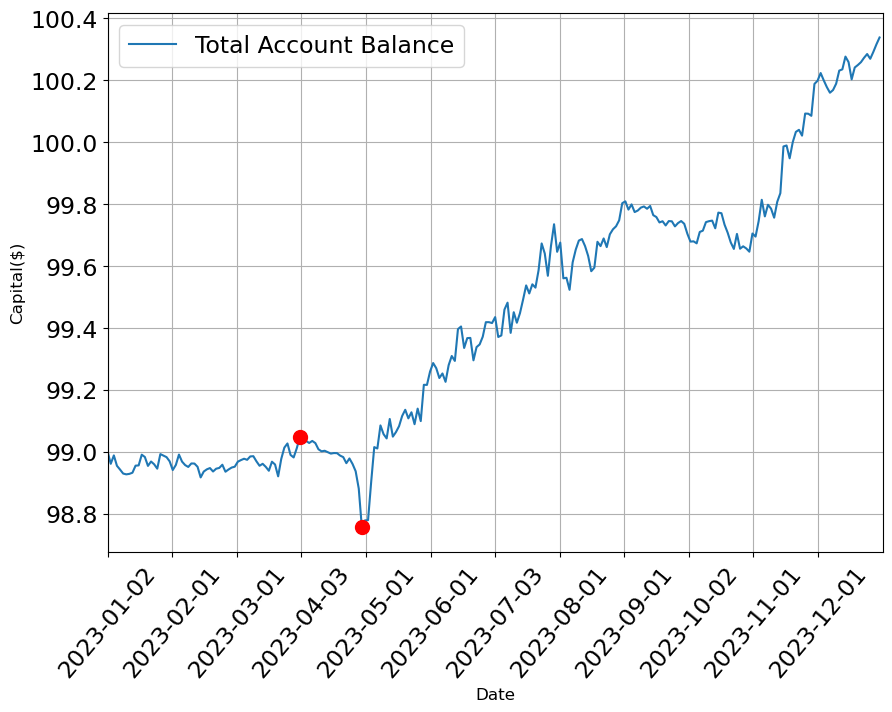

In [17]:
#print('\n')
results, pairs_summary = trader.summarize_results(sharperatio_val,
                                                  cumret_val,
                                                  performance_rnn,
                                                  pairs, ticker_segment_dict,
                                                  n_years=1)

In [18]:
pairs_summary

,Leg1,Leg1_Segmt,Leg2,Leg2_Segmt,t_statistic,p_value,zero_cross,half_life,hurst_exponent,positive_trades,negative_trades,sharpe_result,positive_trades_per_pair_pct
0,CIBR,First Trust NASDAQ Cybersecurity ETF,FTEC,Fidelity MSCI Information Technology Index ETF,-3.164843,0.022112,90,60,0.371820,6,0,1.808718,100.000000
1,CIBR,First Trust NASDAQ Cybersecurity ETF,FTXL,First Trust Nasdaq Semiconductor ETF,-4.462021,0.000230,98,27,0.323979,6,1,1.174466,85.714286
2,CIBR,First Trust NASDAQ Cybersecurity ETF,IYW,iShares U.S. Technology ETF,-3.287700,0.015437,52,56,0.374151,3,0,1.063913,100.000000
3,QQQ,Invesco QQQ Trust,QQQE,Direxion NASDAQ-100 Equal Weighted Index Shares,-2.641148,0.084787,53,71,0.468841,1,0,0.968702,100.000000
4,CIBR,First Trust NASDAQ Cybersecurity ETF,IXN,iShares Global Tech ETF,-3.390555,0.011285,82,52,0.362141,5,0,0.747303,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,FTEC,Fidelity MSCI Information Technology Index ETF,FTXL,First Trust Nasdaq Semiconductor ETF,-3.353953,0.012632,76,26,0.371285,0,2,-2.238992,0.000000
95,NUMG,Nuveen ESG Mid-Cap Growth ETF,XSW,SPDR S&P Software & Services ETF,-3.405776,0.010764,71,46,0.362832,1,0,-2.450504,100.000000
96,HACK,ETFMG Prime Cyber Security ETF,MTUM,iShares MSCI USA Momentum Factor ETF,-3.744531,0.003529,83,35,0.371510,0,1,-3.458881,0.000000
97,SOXX,iShares PHLX Semiconductor ETF,TLTD,FlexShares Morningstar Developed Markets ex-US...,-2.891166,0.046385,61,78,0.484744,0,1,-3.488380,0.000000


In [19]:
results

{'n_pairs': 99,
 'portfolio_sharpe_ratio': np.float64(-0.3880606461670687),
 'avg_total_roi': np.float64(1.3518634891531989),
 'avg_annual_roi': np.float64(1.3518634891531933),
 'pct_positive_trades_per_pair': np.float64(71.9364277697611),
 'pct_pairs_with_positive_results': 25.252525252525253,
 'avg_half_life': np.float64(54.80808080808081),
 'avg_hurst_exponent': np.float64(0.42056527636967955)}

Training:

In [20]:
init = model_rnn[0]['predictions_train'].index[0]
true_train = [pairs[i][2]['spread'][init:train_val_split] for i in range(len(pairs))]
predictions_train = [model_rnn[i]['predictions_train'] for i in range(len(pairs))]
_ = evaluate_forecasting(len(pairs), true_train, predictions_train)

7373.68E-4
676.55E-3
486.00E-3
49.23%


Validation:

In [21]:
true_val = [summaries_rnn[i]['spread(t)'] for i in range(len(pairs))]
predictions = [summaries_rnn[i]['prediction(t)'] for i in range(len(pairs))]
_ = evaluate_forecasting(len(pairs), true_val, predictions)

7208.15E-4
631.74E-3
489.77E-3
49.33%


## **Test unrestricted**

In [22]:
model_rnn, cumret_test, sharperatio_test, summaries_rnn, balance_summaries_rnn = \
        forecasting_trader.test_specific_model(n_in, hidden_nodes, pairs, path=current_path,
                                               low_quantile=low_quantile, high_quantile=high_quantile, lag=1, 
                                               profitable_pairs_indices=range(len(pairs)))

performance_rnn = [(summaries_rnn[i], balance_summaries_rnn[i]) for i in range(len(pairs))]
performance_rnn

[(            prediction(t)  prediction(t+1)  spread(t)  predicted_change(%)  \
  date                                                                         
  2024-02-06      -9.645222                0 -10.062311             0.000000   
  2024-02-07      -9.608477                0 -10.834409             4.510236   
  2024-02-08      -9.801543                0 -10.965751             9.533200   
  2024-02-09      -9.975049                0 -11.328563             9.034512   
  2024-02-12     -10.182567                0 -10.931083            10.115994   
  ...                   ...              ...        ...                  ...   
  2024-12-24     -15.189981                0 -30.692540            49.042148   
  2024-12-26     -15.151774                0 -30.190923            50.633690   
  2024-12-27     -15.183570                0 -29.651516            49.708163   
  2024-12-30     -15.203071                0 -29.742968            48.727509   
  2024-12-31     -15.198106             

Annual ROI:  -0.6630783730110945
43.43434343434343 % of the pairs had positive returns
Sharpe Ratio assumming IID returns:  -0.1908518800278185
Autocorrelation:  -0.04840525267821994
Daily Sharpe Ratio -0.011666981174320067
Total number of trades:  391
Positive trades:  213
Negative trades:  178
Total Drawdown Days: 122 days
Max DD period: 1 days
Maximum drawdown of portfolio: -3.51%


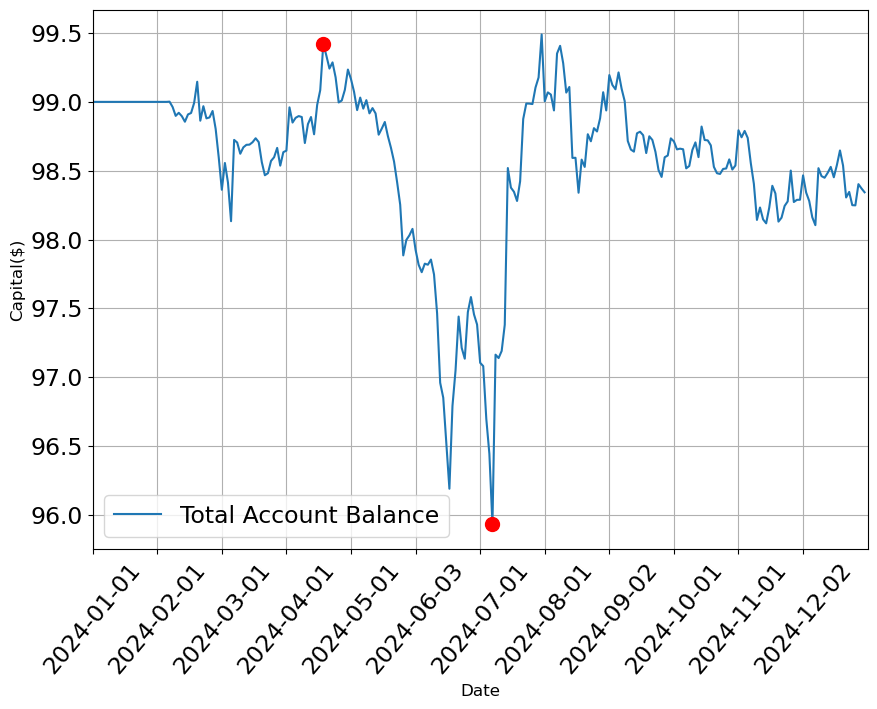

In [23]:
results, pairs_summary = trader.summarize_results(sharperatio_test,
                                                  cumret_test,
                                                  performance_rnn,
                                                  pairs, ticker_segment_dict,
                                                  n_years=1)

In [24]:
results

{'n_pairs': 99,
 'portfolio_sharpe_ratio': np.float64(-0.011666981174320067),
 'avg_total_roi': np.float64(-0.6630783730110966),
 'avg_annual_roi': np.float64(-0.6630783730110945),
 'pct_positive_trades_per_pair': np.float64(52.05504462857404),
 'pct_pairs_with_positive_results': 43.43434343434343,
 'avg_half_life': np.float64(54.80808080808081),
 'avg_hurst_exponent': np.float64(0.42056527636967955)}

In [25]:
pairs_summary

,Leg1,Leg1_Segmt,Leg2,Leg2_Segmt,t_statistic,p_value,zero_cross,half_life,hurst_exponent,positive_trades,negative_trades,sharpe_result,positive_trades_per_pair_pct
0,CIBR,First Trust NASDAQ Cybersecurity ETF,IYW,iShares U.S. Technology ETF,-3.287700,0.015437,52,56,0.374151,3,2,1.193754,60.000000
1,CIBR,First Trust NASDAQ Cybersecurity ETF,FTEC,Fidelity MSCI Information Technology Index ETF,-3.164843,0.022112,90,60,0.371820,5,4,0.969619,55.555556
2,SOXL,Direxion Daily Semiconductor Bull 3X Shares,TQQQ,ProShares UltraPro QQQ,-2.927179,0.042278,55,29,0.407742,6,2,0.963550,75.000000
3,CIBR,First Trust NASDAQ Cybersecurity ETF,NXTG,First Trust IndXX NextG ETF,-4.370361,0.000335,73,30,0.382863,3,0,0.645661,100.000000
4,CIBR,First Trust NASDAQ Cybersecurity ETF,TDIV,First Trust NASDAQ Technology Dividend Index Fund,-4.075487,0.001063,80,40,0.379157,1,0,0.635884,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,QTEC,First Trust NASDAQ-100-Technology Sector Index...,QYLD,Global X NASDAQ 100 Covered Call ETF,-3.743580,0.003540,102,27,0.405202,0,1,-2.761470,0.000000
95,HACK,ETFMG Prime Cyber Security ETF,IGV,iShares Expanded Tech-Software Sector ETF,-3.520569,0.007474,62,59,0.395419,0,4,-3.042733,0.000000
96,IEFA,iShares Core MSCI EAFE ETF,IGM,iShares Expanded Tech Sector ETF,-3.139374,0.023773,69,62,0.487156,0,1,-4.180583,0.000000
97,QYLD,Global X NASDAQ 100 Covered Call ETF,ROM,ProShares Ultra Technology,-3.502889,0.007913,57,31,0.419513,0,1,-4.352687,0.000000


Test:

In [26]:
true_test = [summaries_rnn[i]['spread(t)'] for i in range(len(pairs))]
predictions = [summaries_rnn[i]['prediction(t)'] for i in range(len(pairs))]
_ = evaluate_forecasting(len(pairs), true_test, predictions)

77780.88E-4
1770.00E-3
1335.84E-3
47.83%


## **Test with active pairs on validation set**

In [27]:
cumret_val = np.asarray(cumret_val)
profitable_pairs_indices = np.argwhere(cumret_val > 0)
profitable_pairs = [pairs[i] for i in profitable_pairs_indices.flatten()]
model_rnn, cumret_test, sharperatio_test, summaries_rnn, balance_summaries_rnn = \
        forecasting_trader.test_specific_model(n_in, hidden_nodes, pairs, path=current_path,
                                               low_quantile=low_quantile, high_quantile=high_quantile, lag=1, 
                                               profitable_pairs_indices=profitable_pairs_indices)
performance_rnn = [(summaries_rnn[i], balance_summaries_rnn[i]) for i in range(len(profitable_pairs))]
performance_rnn

[(            prediction(t)  prediction(t+1)  spread(t)  predicted_change(%)  \
  date                                                                         
  2024-02-06      -4.754429                0  -4.690164             0.000000   
  2024-02-07      -4.631105                0  -4.436687             1.259207   
  2024-02-08      -4.330238                0  -4.413795             2.399292   
  2024-02-09      -4.157628                0  -3.736530             5.803791   
  2024-02-12      -3.597007                0  -3.696480             3.734030   
  ...                   ...              ...        ...                  ...   
  2024-12-24       8.341699                0  13.892155           -27.657063   
  2024-12-26       9.455613                0  14.630235           -31.935592   
  2024-12-27      10.257909                0  13.268320           -29.885548   
  2024-12-30      10.207009                0  11.844042           -23.072329   
  2024-12-31       9.636167             

Annual ROI:  0.6815966583812116
60.0 % of the pairs had positive returns
Sharpe Ratio assumming IID returns:  -1.3604489362881271
Autocorrelation:  0.09793712741243117
Daily Sharpe Ratio -0.08248826298042404
Total number of trades:  153
Positive trades:  73
Negative trades:  80
Total Drawdown Days: 110 days
Max DD period: 1 days
Maximum drawdown of portfolio: -4.57%


{'n_pairs': 25,
 'portfolio_sharpe_ratio': np.float64(-0.08248826298042404),
 'avg_total_roi': np.float64(0.6815966583812062),
 'avg_annual_roi': np.float64(0.6815966583812116),
 'pct_positive_trades_per_pair': np.float64(52.47325319016496),
 'pct_pairs_with_positive_results': 60.0,
 'avg_half_life': np.float64(53.76),
 'avg_hurst_exponent': np.float64(0.3919878807448647)}

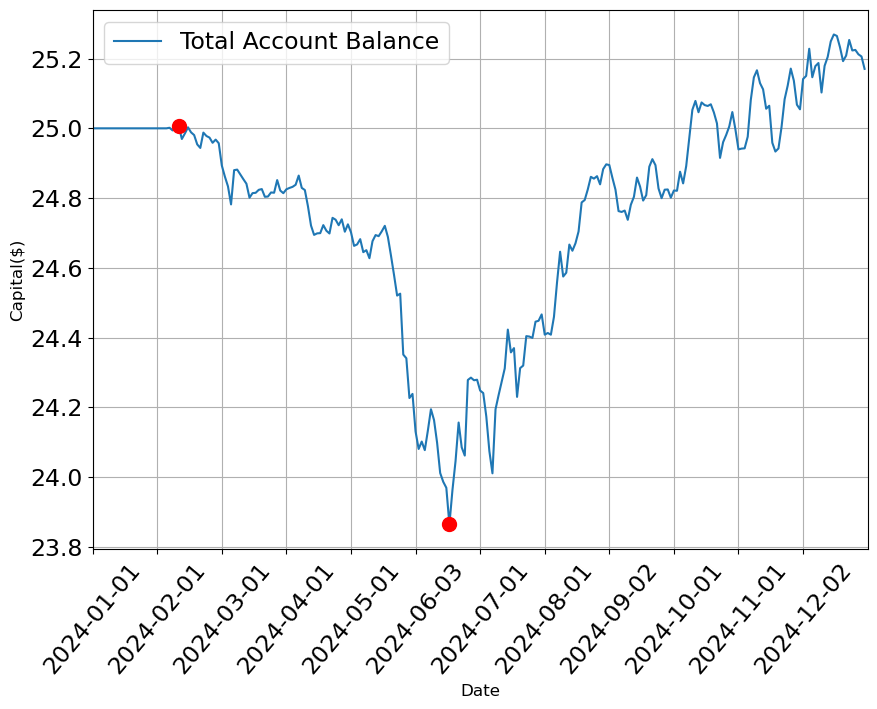

In [28]:
results, pairs_summary = trader.summarize_results(sharperatio_test,
                                                  cumret_test,
                                                  performance_rnn,
                                                  profitable_pairs, ticker_segment_dict,
                                                  n_years=1)
results

In [29]:
pairs_summary

,Leg1,Leg1_Segmt,Leg2,Leg2_Segmt,t_statistic,p_value,zero_cross,half_life,hurst_exponent,positive_trades,negative_trades,sharpe_result,positive_trades_per_pair_pct
0,CIBR,First Trust NASDAQ Cybersecurity ETF,IYW,iShares U.S. Technology ETF,-3.287700,0.015437,52,56,0.374151,3,2,1.193754,60.000000
1,CIBR,First Trust NASDAQ Cybersecurity ETF,FTEC,Fidelity MSCI Information Technology Index ETF,-3.164843,0.022112,90,60,0.371820,5,4,0.969619,55.555556
2,SOXX,iShares PHLX Semiconductor ETF,SUSA,iShares MSCI USA ESG Select ETF,-2.868402,0.049148,123,39,0.348150,5,1,0.317978,83.333333
3,CIBR,First Trust NASDAQ Cybersecurity ETF,FTXL,First Trust Nasdaq Semiconductor ETF,-4.462021,0.000230,98,27,0.323979,12,5,0.270855,70.588235
4,FTC,First Trust Large Cap Growth AlphaDEX Fund,FTXL,First Trust Nasdaq Semiconductor ETF,-2.754777,0.065030,74,54,0.429365,4,4,0.110006,50.000000
5,CIBR,First Trust NASDAQ Cybersecurity ETF,NULG,Nuveen ESG Large-Cap Growth ETF,-3.299189,0.014915,81,46,0.370175,3,1,0.010191,75.000000
6,HACK,ETFMG Prime Cyber Security ETF,NXTG,First Trust IndXX NextG ETF,-3.291711,0.015253,55,64,0.413656,0,0,0.000000,NaN
7,HACK,ETFMG Prime Cyber Security ETF,IGM,iShares Expanded Tech Sector ETF,-3.062577,0.029450,60,75,0.384990,1,0,-0.057816,100.000000
8,HACK,ETFMG Prime Cyber Security ETF,NULG,Nuveen ESG Large-Cap Growth ETF,-2.742574,0.066956,64,92,0.384321,1,0,-0.231446,100.000000
9,CIBR,First Trust NASDAQ Cybersecurity ETF,IXN,iShares Global Tech ETF,-3.390555,0.011285,82,52,0.362141,2,4,-0.238004,33.333333
